# LeetCode #118: Pascal's Triangle

https://leetcode.com/problems/pascals-triangle/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(n^2)$ |
| **Row-by-Row Simulation** ★ | $O(n^2)$ | $O(n^2)$ |

---

## Understanding the Methods

### Brute Force
Compute each cell independently using the binomial formula $C(i, k) = i! / (k! \cdot (i-k)!)$. Requires factorial arithmetic per cell and treats each value in isolation, offering no reuse of adjacent computations.

### Optimal: Row-by-Row Simulation ★
Start each new row with 1s at both endpoints, then fill interior positions by summing the two values directly above from the previous row. Each addition reuses already-computed values — no factorial math, no redundant work.

**Why this is better than Brute Force:** Avoids repeated factorial computation by deriving every interior value from a single addition, making the code simpler and immune to integer overflow from large factorials.

**Constraints:**
* 1 ≤ numRows ≤ 30

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<int>> Generate(int numRows) {
        var result = new List<IList<int>>();
        for (int i = 0; i < numRows; i++) {
            var row = new List<int> { 1 };
            // Each interior element is the sum of the two elements directly above
            for (int j = 1; j < i; j++)
                row.Add(result[i-1][j-1] + result[i-1][j]);
            if (i > 0) row.Add(1);
            result.Add(row);
        }
        return result;
    }
}

### Python

In [ ]:
class Solution:
    def generate(self, numRows: int) -> List[List[int]]:
        result = []
        for i in range(numRows):
            row = [1]
            # Each interior element is the sum of the two elements directly above
            for j in range(1, i):
                row.append(result[i-1][j-1] + result[i-1][j])
            if i > 0:
                row.append(1)
            result.append(row)
        return result

### Go

In [ ]:
func generate(numRows int) [][]int {
    result := make([][]int, numRows)
    for i := 0; i < numRows; i++ {
        row := make([]int, i+1)
        row[0], row[i] = 1, 1
        // Each interior element is the sum of the two elements directly above
        for j := 1; j < i; j++ {
            row[j] = result[i-1][j-1] + result[i-1][j]
        }
        result[i] = row
    }
    return result
}

### Rust

In [ ]:
pub fn generate(num_rows: i32) -> Vec<Vec<i32>> {
    let mut result: Vec<Vec<i32>> = Vec::new();
    for i in 0..num_rows as usize {
        let mut row = vec![1; i + 1];
        // Each interior element is the sum of the two elements directly above
        for j in 1..i {
            row[j] = result[i-1][j-1] + result[i-1][j];
        }
        result.push(row);
    }
    result
}

## Example Scenarios

**1. Common Case**
**Input:** numRows = 5
Row 0: [1]. Row 1: [1,1]. Row 2: [1, 1+1=2, 1] → [1,2,1]. Row 3: [1, 1+2=3, 2+1=3, 1] → [1,3,3,1]. Row 4: [1, 1+3=4, 3+3=6, 3+1=4, 1] → [1,4,6,4,1]. Output: **[[1],[1,1],[1,2,1],[1,3,3,1],[1,4,6,4,1]]**.

**2. Slightly Complex — row 5 extends the pattern**
**Input:** numRows = 6
Row 5 interior: prev=[1,4,6,4,1] → 1+4=5, 4+6=10, 6+4=10, 4+1=5. Row 5 = [1,5,10,10,5,1]. These are exactly the binomial coefficients $C(5,0)\ldots C(5,5)$ — each row $i$ encodes the coefficients of $(a+b)^i$.

**3. Edge Case: Time Factor — numRows = 30**
Row 30 has 30 elements; total cells = $1+2+\cdots+30 = 465$. Each cell costs exactly one addition, so total work is 465 − 30 = 435 additions (endpoints are free). Brute Force with factorials would compute 30! $\approx 2.65 \times 10^{32}$ — far beyond any integer type. Simulation never exceeds 155,117,520 (the largest C(30,15)) which fits in a 32-bit int.

**4. Edge Case: Space Factor — output dominates, no auxiliary needed**
**Input:** numRows = 30
All $\frac{n(n+1)}{2} = 465$ integers are stored in the output structure. Each new row reads only the immediately preceding row — no extra copy is held simultaneously. Auxiliary space beyond the output: $O(n)$ per row (the row under construction), discarded after appending.

**5. Almost-Impossible but Plausible — numRows = 1**
**Input:** numRows = 1
i=0: row starts as [1]. Inner loop range (1..0) is empty. The `if i > 0` branch is skipped. Row [1] appended. Returns **[[1]]** — one iteration, zero additions.

## Infographic

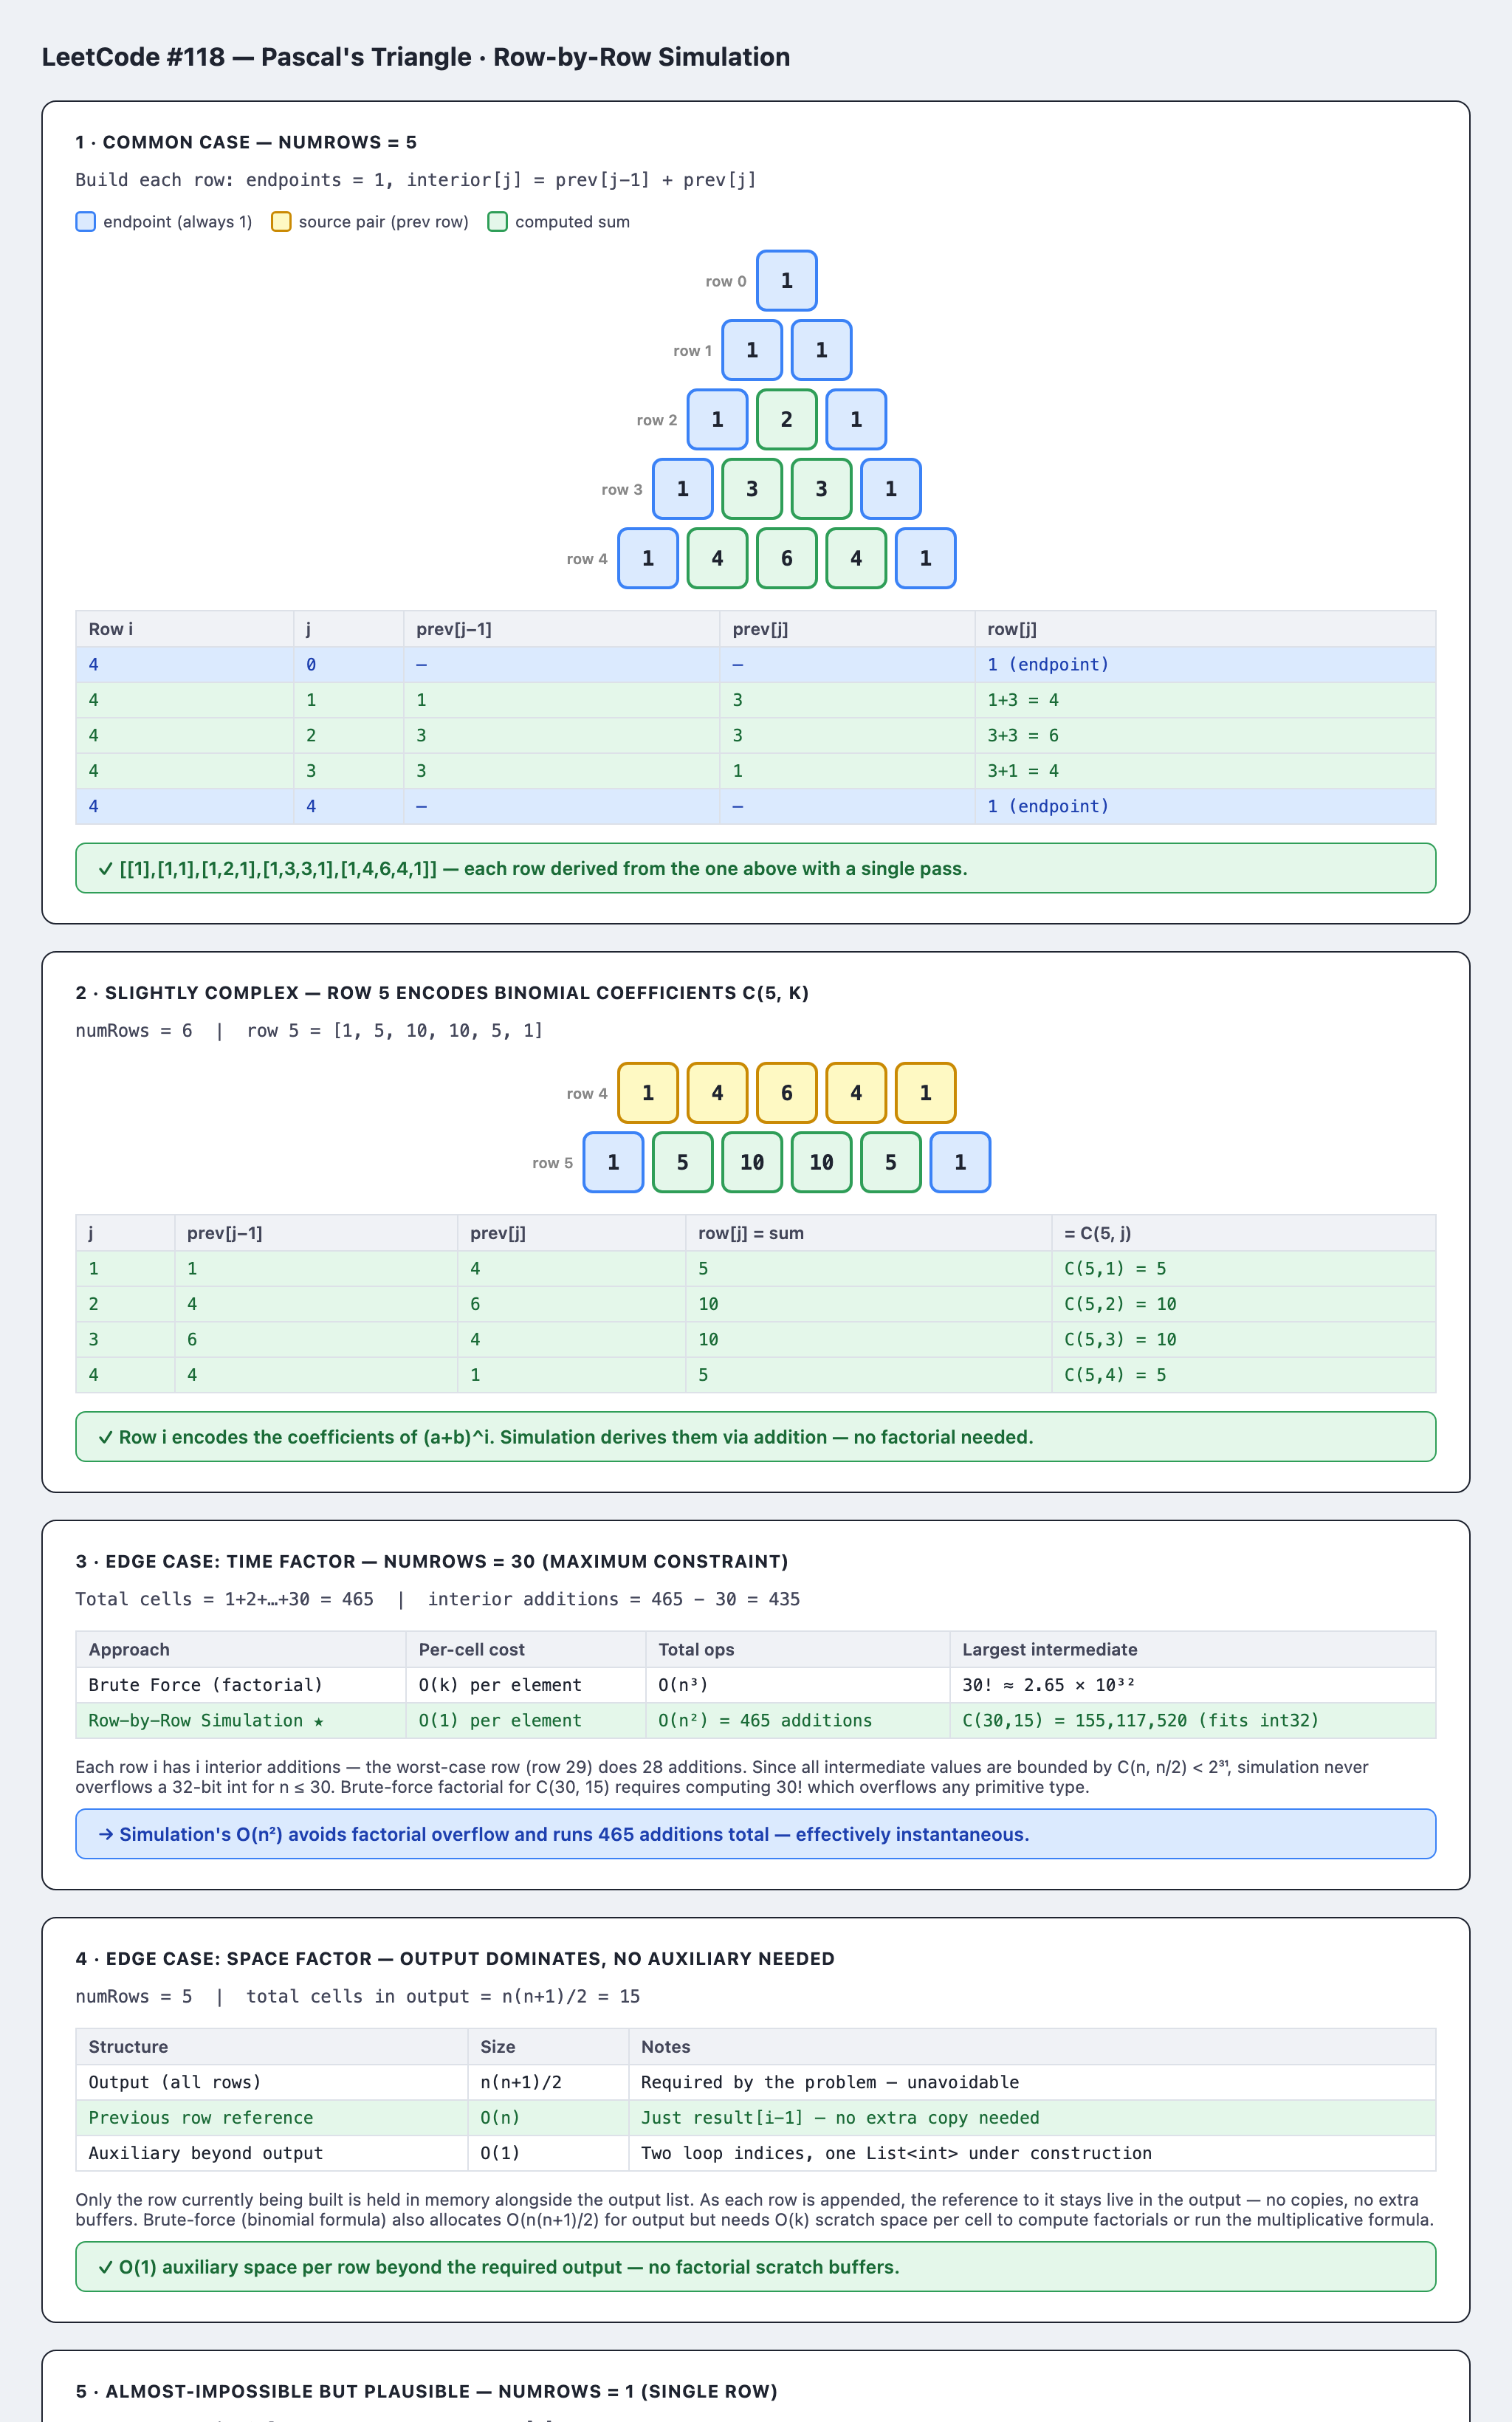